# Edge Detection Assignment: Sobel and Canny (From Scratch)

In this assignment you will implement two classical edge detection methods:

- **Sobel Edge Detector**
- **Canny Edge Detector**

The goal is to understand the internal steps of these algorithms rather than using ready-made implementations.

---

## Important Restrictions

You **must NOT use OpenCV edge detection functions**, including:

- `cv2.Sobel`
- `cv2.Canny`
- `cv2.filter2D`
- `cv2.GaussianBlur`

You should implement the core operations **manually using NumPy**.

You may use libraries such as:

- `numpy`
- `matplotlib`
- `PIL` (for reading images)

---

## What You Will Implement

1. A **2D convolution function**
2. **Sobel gradient computation**
3. **Gaussian smoothing**
4. **Non‑Maximum Suppression**
5. **Double thresholding**
6. **Edge tracking by hysteresis**

---

## Images Used

Two types of images will be tested:

1. **Synthetic image** (simple shapes)
2. **Real-world road image**

This allows comparing behavior on clean vs complex scenes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from PIL import Image

plt.rcParams["figure.figsize"] = (6,6)

def show_image(img, title="", cmap="gray"):
    """
    Display a single image.
    Works for both grayscale and RGB images.
    """
    plt.figure()

    if img.ndim == 2:
        plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
    else:
        plt.imshow(img.astype(np.uint8))

    plt.title(title)
    plt.axis("off")
    plt.show()


def show_grid(images, titles=None, ncols=3, cmap="gray"):
    """
    Display multiple images in a grid layout.
    """
    n = len(images)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig = plt.figure(figsize=(4*ncols, 4*nrows))
    gs = gridspec.GridSpec(nrows, ncols, figure=fig)

    for i, img in enumerate(images):
        ax = fig.add_subplot(gs[i])

        if img.ndim == 2:
            ax.imshow(img, cmap=cmap, vmin=0, vmax=255)
        else:
            ax.imshow(img.astype(np.uint8))

        if titles is not None:
            ax.set_title(titles[i])

        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Step 1 — Load the Images

We will work with two images:

### 1. Synthetic Image
A simple image containing geometric shapes.  
This helps understand edge behavior in a clean environment.

### 2. Real Road Image
A more complex real-world image containing a road and vehicles.  
This allows observing how edge detection behaves in realistic conditions.

The road image will be converted to **grayscale** before processing.


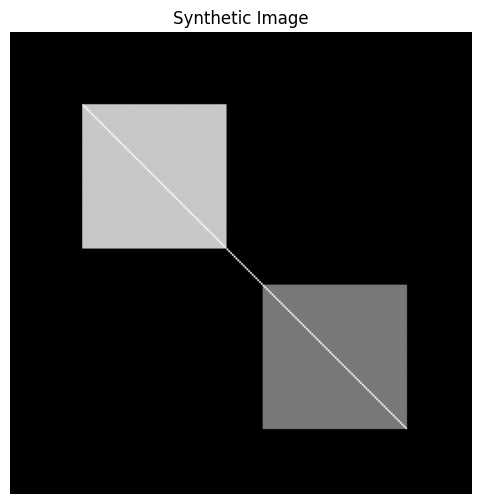

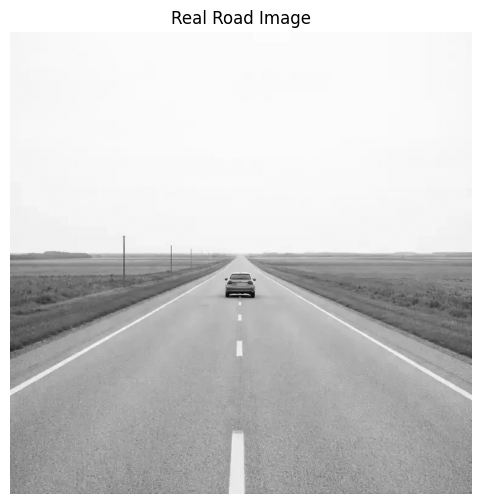

In [2]:
def create_synthetic_image(size=256):
    """
    Create a simple synthetic image with geometric shapes.
    """
    img = np.zeros((size, size), dtype=np.uint8)

    # white square
    img[40:120, 40:120] = 200

    # gray square
    img[140:220, 140:220] = 120

    # diagonal line
    for i in range(40, 220):
        if i < size and i < size:
            img[i, i] = 255

    return img


# synthetic image
synthetic_img = create_synthetic_image()


# real image (road)
real_img_path = "road_image.png"

real_img = Image.open(real_img_path).convert("L")
real_img = np.array(real_img, dtype=np.uint8)


show_image(synthetic_img, "Synthetic Image")
show_image(real_img, "Real Road Image")

## Step 2 — Implement 2D Convolution

Many image processing operations can be expressed using **2D convolution**.

Given an image \(I\) and a kernel \(K\), convolution applies the kernel to every pixel
by multiplying neighboring pixels with the kernel values and summing them.

The output value at location \((i,j)\) is:

$$(I * K)(i,j) = \sum_m \sum_n I(i+m, j+n) K(m,n)$$


### Why Convolution?

Convolution is the core operation behind:

- Gaussian smoothing
- Sobel gradients
- Laplacian filters
- Many other image processing operators

### Implementation Notes

**Fast vectorized approach:** Instead of nested Python loops (slow), I use **stride tricks** (`as_strided`) to create a view of all overlapping patches simultaneously, then perform the dot product with the flipped kernel in one NumPy operation.

This is equivalent to the loop-based approach but **orders of magnitude faster** on large images.


In [11]:
from numpy.lib.stride_tricks import as_strided

def convolve2d(image, kernel):
    """
    Perform 2D convolution using zero padding.

    Parameters
    ----------
    image : 2D numpy array
        Input grayscale image

    kernel : 2D numpy array
        Convolution kernel (assumed odd size)

    Returns
    -------
    output : 2D numpy array
        Filtered image (float64)
    """
    image = image.astype(np.float64)
    kernel = kernel.astype(np.float64)

    H, W   = image.shape
    kH, kW = kernel.shape

    # padding so output has same size as input
    pad_h = kH // 2
    pad_w = kW // 2

    # zero-pad the image
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    # --- Vectorized convolution via stride tricks ---
    # Create a shape-(H, W, kH, kW) view where [i,j] holds the kH×kW patch
    # centred at pixel (i,j) in the padded image.

    s0, s1 = padded.strides  # byte strides of the padded array
    patches = as_strided(
        padded,
        shape=(H, W, kH, kW),
        strides=(s0, s1, s0, s1)
    )

    # Flip the kernel for true convolution (correlation uses unflipped kernel)
    kernel_flipped = kernel[::-1, ::-1]

    # Element-wise multiply and sum over the kernel dimensions
    output = np.einsum('ijkl,kl->ij', patches, kernel_flipped)

    return output

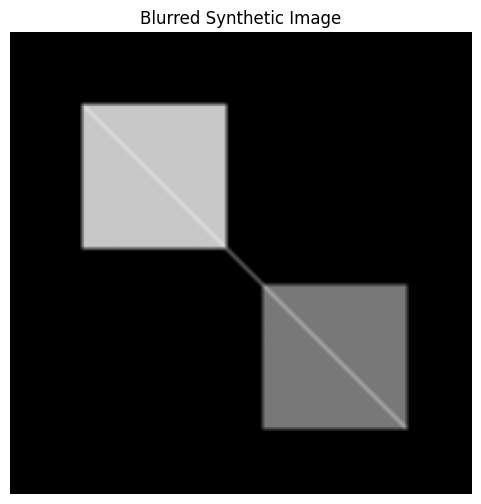

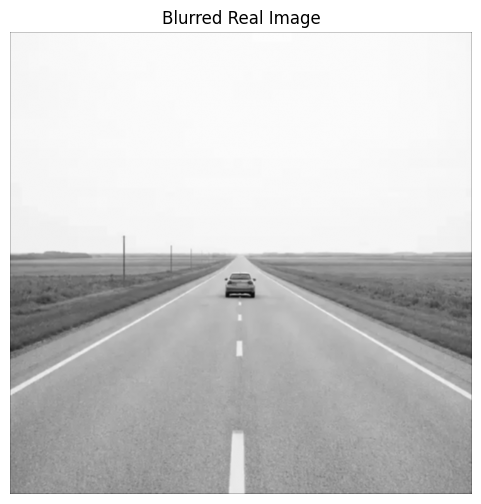

In [12]:
# simple blur kernel
test_kernel = np.ones((3,3)) / 9

synthetic_blur = convolve2d(synthetic_img, test_kernel)
real_blur = convolve2d(real_img, test_kernel)

show_image(synthetic_blur, "Blurred Synthetic Image")
show_image(real_blur, "Blurred Real Image")

#### conv2d function with padding options

In [13]:
import numpy as np
from numpy.lib.stride_tricks import as_strided


def convolve2d_padding(image, kernel, padding_type='zero'):
    """
    Perform 2D convolution with selectable padding type.

    Parameters
    ----------
    image : 2D numpy array
        Input grayscale image

    kernel : 2D numpy array
        Convolution kernel (assumed odd size)

    padding_type : str, optional
        Type of padding to apply. Options:
        - 'zero': Zero padding (default)
        - 'constant': Constant value padding (same as 'zero')
        - 'reflect': Reflection padding (mirror without edge repetition)
        - 'wrap': Wrap-around / circular padding
        Default is 'zero'

    Returns
    -------
    output : 2D numpy array
        Filtered image (float64)

    Raises
    ------
    ValueError
        If padding_type is not one of the supported options
    """
    image = image.astype(np.float64)
    kernel = kernel.astype(np.float64)

    H, W   = image.shape
    kH, kW = kernel.shape

    # padding so output has same size as input
    pad_h = kH // 2
    pad_w = kW // 2

    # Validate padding type
    valid_padding_types = ['zero', 'constant', 'reflect', 'wrap']
    if padding_type not in valid_padding_types:
        raise ValueError(
            f"padding_type must be one of {valid_padding_types}, "
            f"got '{padding_type}'"
        )

    # Apply padding based on type
    if padding_type in ['zero', 'constant']:
        padded = np.pad(
            image,
            ((pad_h, pad_h), (pad_w, pad_w)),
            mode='constant',
            constant_values=0
        )
    elif padding_type == 'reflect':
        padded = np.pad(
            image,
            ((pad_h, pad_h), (pad_w, pad_w)),
            mode='reflect'
        )
    elif padding_type == 'wrap':
        padded = np.pad(
            image,
            ((pad_h, pad_h), (pad_w, pad_w)),
            mode='wrap'
        )

    # --- Vectorized convolution via stride tricks ---
    # Create a shape-(H, W, kH, kW) view where [i,j] holds the kH×kW patch
    # centred at pixel (i,j) in the padded image.

    s0, s1 = padded.strides  # byte strides of the padded array
    patches = as_strided(
        padded,
        shape=(H, W, kH, kW),
        strides=(s0, s1, s0, s1)
    )

    # Flip the kernel for true convolution (correlation uses unflipped kernel)
    kernel_flipped = kernel[::-1, ::-1]

    # Element-wise multiply and sum over the kernel dimensions
    output = np.einsum('ijkl,kl->ij', patches, kernel_flipped)

    return output

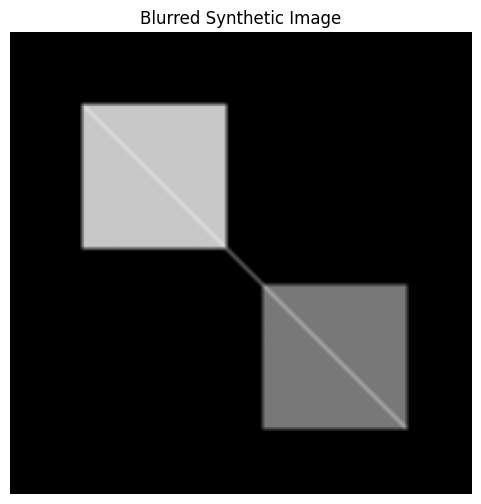

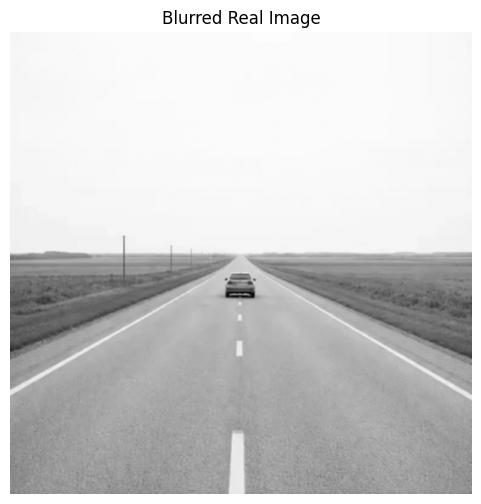

In [14]:
# simple blur kernel
test_kernel = np.ones((3,3)) / 9

synthetic_blur_ref = convolve2d_padding(synthetic_img, test_kernel, padding_type='reflect')
real_blur_ref = convolve2d_padding(real_img, test_kernel, padding_type='reflect')

show_image(synthetic_blur_ref, "Blurred Synthetic Image")
show_image(real_blur_ref, "Blurred Real Image")

## Step 3 — Sobel Edge Detection

Edges correspond to locations where the **image intensity changes rapidly**.

To detect edges we compute the **image gradient**.

The gradient has two components:

- Horizontal gradient \(G_x\)
- Vertical gradient \(G_y\)

The Sobel operator approximates these derivatives using the following kernels.

### Sobel Kernels

Horizontal gradient:


G_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}


Vertical gradient:


G_y =
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}


### Gradient Magnitude

After computing \(G_x\) and \(G_y\), the edge strength is


$$G = sqrt(G_x^2 + G_y^2)$$


### Your Task

1. Define the Sobel kernels
2. Use your `convolve2d` function to compute \(G_x\) and \(G_y\)
3. Compute the **gradient magnitude**
4. Visualize the results


In [24]:
def sobel_edges(image):
    """
    Compute Sobel edge magnitude and direction.

    Parameters
    ----------
    image : 2D numpy array (grayscale)

    Returns
    -------
    magnitude_norm : 2D numpy array
        Edge strength, normalized to [0, 255]

    direction : 2D numpy array
        Gradient angle in degrees
    """

    # Define Sobel kernels
    # Gx detects horizontal changes (vertical edges)
    Gx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float64)

    # Gy detects vertical changes (horizontal edges)
    Gy = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=np.float64)

    # Compute gradients using convolve2d
    grad_x = convolve2d_padding(image, Gx)
    grad_y = convolve2d_padding(image, Gy)

    # Gradient magnitude: sqrt(Gx^2 + Gy^2)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)

    # Gradient direction in degrees
    direction = np.degrees(np.arctan2(grad_y, grad_x))

    # Normalize magnitude to [0, 255] for visualization
    max_val = magnitude.max()
    if max_val > 0:
        magnitude_norm = (magnitude / max_val * 255).astype(np.float32)
    else:
        magnitude_norm = magnitude.astype(np.float32)

    return magnitude_norm, direction

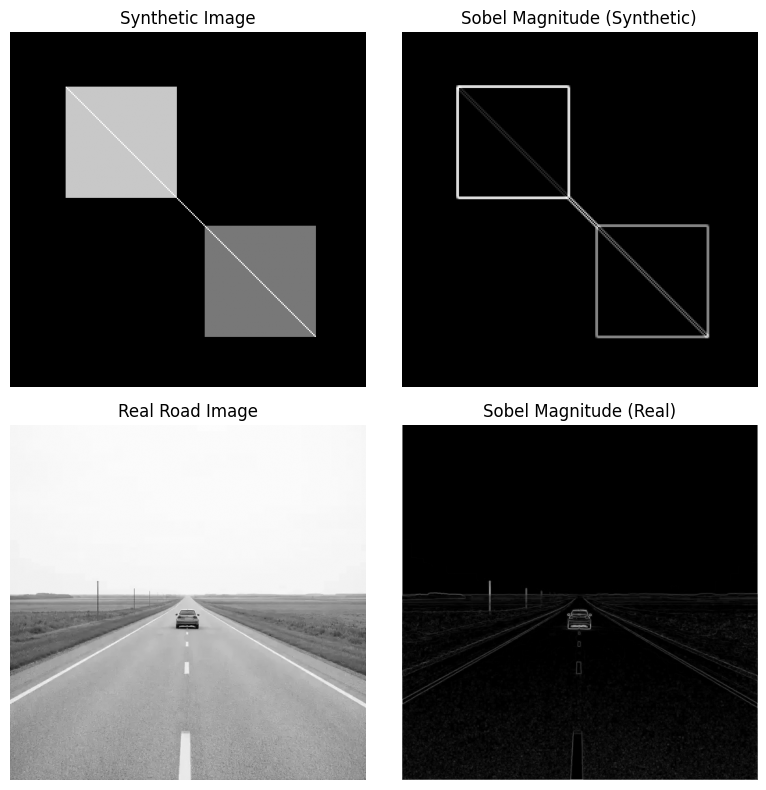

In [25]:
# compute sobel edges
syn_mag, syn_dir = sobel_edges(synthetic_img)
real_mag, real_dir = sobel_edges(real_img)

# visualize results
show_grid(
    [synthetic_img, syn_mag, real_img, real_mag],
    [
        "Synthetic Image",
        "Sobel Magnitude (Synthetic)",
        "Real Road Image",
        "Sobel Magnitude (Real)"
    ],
    ncols=2
)

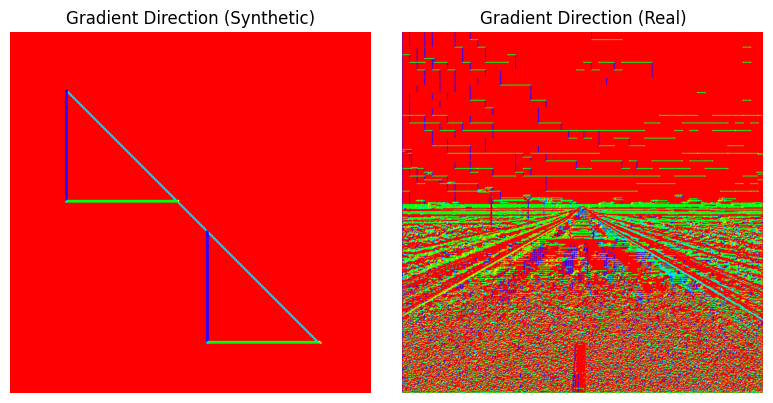

In [26]:
show_grid(
    [syn_dir, real_dir],
    [
        "Gradient Direction (Synthetic)",
        "Gradient Direction (Real)"
    ],
    ncols=2,
    cmap="hsv"
)

## Step 4 — Gaussian Smoothing

Before detecting edges, Canny first applies **Gaussian smoothing**.

Why?

Gradient-based edge detection is **very sensitive to noise**.  
Gaussian filtering reduces noise while preserving large-scale structures.

The Gaussian kernel is defined as:

$$
G(x,y) =
\frac{1}{2\pi\sigma^2}
e^{-\frac{x^2+y^2}{2\sigma^2}}
$$

### Your Task

Implement a function:
`gaussian_kernel(size, sigma)`


Requirements:

- Kernel size must be **odd**
- Values must follow the Gaussian formula
- Normalize the kernel so that **sum = 1**

Then we will apply this kernel using the previously implemented **convolution function**.

### Implementation Note

We use `np.meshgrid` to build the 2D coordinate grid in one vectorized call, avoiding loops entirely. The result is normalized so that all values sum to 1 (probability distribution).


In [27]:
def gaussian_kernel(size=5, sigma=1.0):
    """
    Create a normalized Gaussian kernel.

    Parameters
    ----------
    size : int
        Kernel size (must be odd)

    sigma : float
        Standard deviation of Gaussian

    Returns
    -------
    kernel : 2D numpy array
        Normalized Gaussian kernel of shape (size, size)
    """
    assert size % 2 == 1, "Kernel size must be odd"

    # coordinate grid centered at zero
    # e.g. for size=5: [-2, -1, 0, 1, 2]
    half = size // 2
    ax = np.arange(-half, half + 1, dtype=np.float64)

    # 2D grid via meshgrid (vectorized, no loops)
    xx, yy = np.meshgrid(ax, ax)

    # Gaussian formula: exp(-(x^2 + y^2) / (2*sigma^2))
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))

    # Normalize so the sum equals 1
    kernel = kernel / kernel.sum()

    return kernel

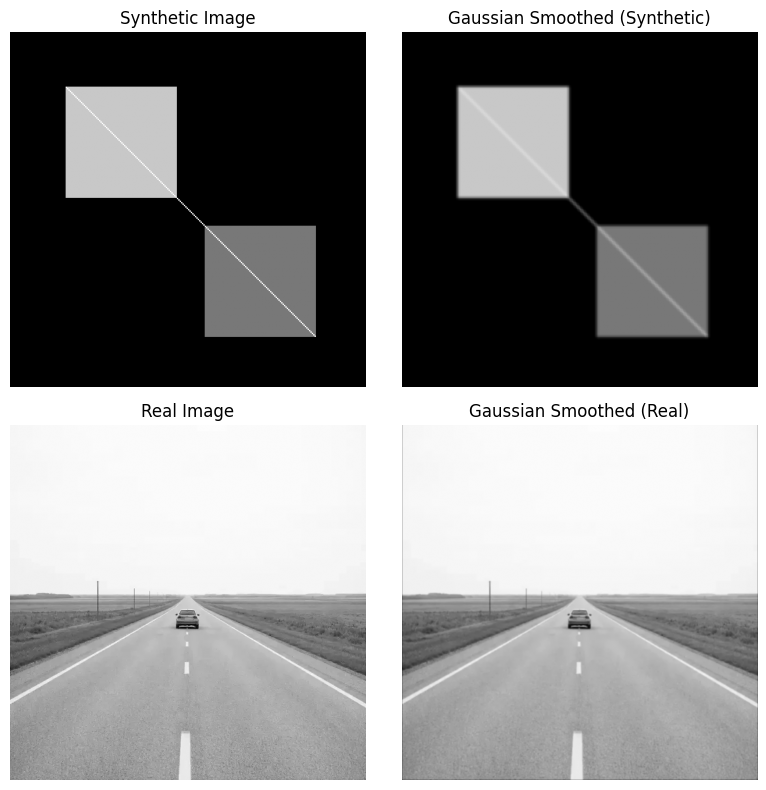

In [28]:
# create gaussian kernel
kernel = gaussian_kernel(size=5, sigma=1.0)

# smooth images
synthetic_smooth = convolve2d(synthetic_img, kernel)
real_smooth = convolve2d(real_img, kernel)

show_grid(
    [synthetic_img, synthetic_smooth, real_img, real_smooth],
    [
        "Synthetic Image",
        "Gaussian Smoothed (Synthetic)",
        "Real Image",
        "Gaussian Smoothed (Real)"
    ],
    ncols=2
)

## Step 5 — Non‑Maximum Suppression (NMS)

After computing the gradient magnitude using Sobel, the detected edges are usually **thick**.
However, real edges should ideally be **one pixel wide**.

Non‑Maximum Suppression is used to **thin the edges**.

### Idea

For each pixel:

1. Look at the **gradient direction**.
2. Compare the pixel's gradient magnitude with its **two neighbors along the gradient direction**.
3. If the pixel is **not the local maximum**, suppress it (set it to 0).

### Direction Quantization

For simplicity, gradient directions are quantized into four main directions:

- **0°**  → compare left and right
- **45°** → compare diagonal neighbors
- **90°** → compare up and down
- **135°** → compare the other diagonal

### Your Task

Implement:
`non_maximum_suppression(magnitude, direction)`


Input:

- gradient magnitude
- gradient direction

Output:

- thinned edge map


In [29]:
def non_maximum_suppression(magnitude, direction):
    """
    Perform Non-Maximum Suppression (fully vectorized).
    Gradient directions are quantized to 4 angles:
      0°   → horizontal  (compare left / right)
      45°  → diagonal    (compare top-right / bottom-left)
      90°  → vertical    (compare top / bottom)
      135° → anti-diag   (compare top-left / bottom-right)

    Parameters
    ----------
    magnitude : 2D numpy array
        Gradient magnitude

    direction : 2D numpy array
        Gradient direction in degrees

    Returns
    -------
    nms : 2D numpy array
        Suppressed edge map (same shape as magnitude)
    """
    H, W = magnitude.shape
    nms  = np.zeros((H, W), dtype=np.float32)

    # Map all angles to [0, 180)
    angle = direction % 180

    # Interior slice (avoid border pixels)
    m = magnitude[1:-1, 1:-1]

    # Quantize angle and build boolean masks for the 4 directions
    a = angle[1:-1, 1:-1]

    # 0°  region: [0, 22.5) or [157.5, 180)  → horizontal neighbors
    mask0 = (a < 22.5) | (a >= 157.5)
    # 45° region: [22.5, 67.5)
    mask45 = (a >= 22.5) & (a < 67.5)
    # 90° region: [67.5, 112.5)
    mask90 = (a >= 67.5) & (a < 112.5)
    # 135° region: [112.5, 157.5)
    mask135 = (a >= 112.5) & (a < 157.5)

    # For each direction mask, compare current pixel with both neighbors
    # Keep only if it is ≥ both neighbors (local maximum)
    interior = nms[1:-1, 1:-1]

    # 0° — compare with left (col-1) and right (col+1)
    n1 = magnitude[1:-1, :-2]   # left neighbor
    n2 = magnitude[1:-1, 2:]    # right neighbor
    interior[mask0] = np.where(mask0 & (m >= n1) & (m >= n2), m, 0)[mask0]

    # 45° — compare with top-right and bottom-left
    n1 = magnitude[:-2, 2:]     # top-right
    n2 = magnitude[2:, :-2]     # bottom-left
    interior[mask45] = np.where(mask45 & (m >= n1) & (m >= n2), m, 0)[mask45]

    # 90° — compare with top and bottom
    n1 = magnitude[:-2, 1:-1]   # top
    n2 = magnitude[2:, 1:-1]    # bottom
    interior[mask90] = np.where(mask90 & (m >= n1) & (m >= n2), m, 0)[mask90]

    # 135° — compare with top-left and bottom-right
    n1 = magnitude[:-2, :-2]    # top-left
    n2 = magnitude[2:, 2:]      # bottom-right
    interior[mask135] = np.where(mask135 & (m >= n1) & (m >= n2), m, 0)[mask135]

    return nms

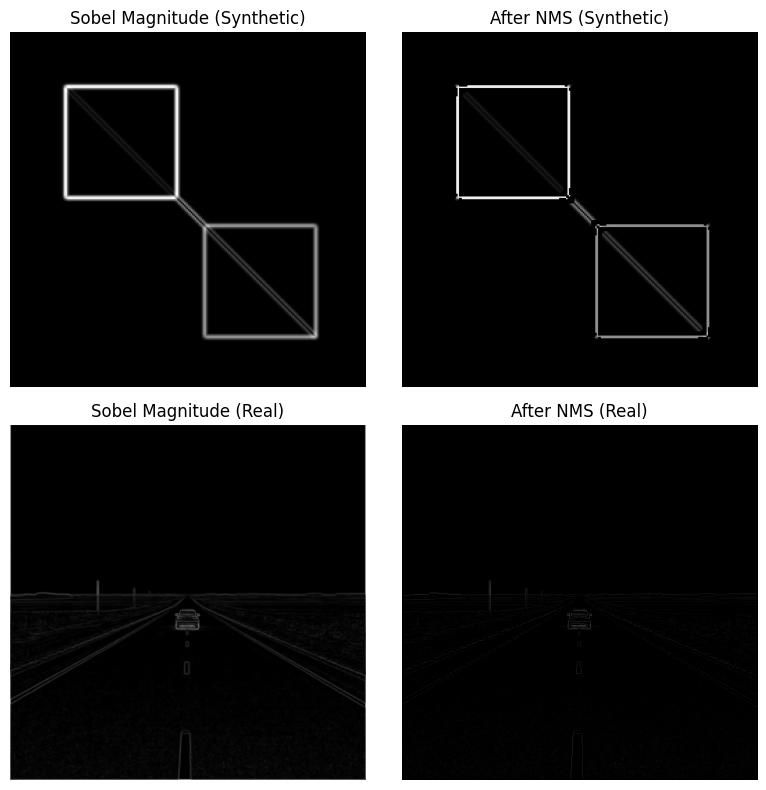

In [30]:
# recompute sobel on smoothed images
syn_mag, syn_dir = sobel_edges(synthetic_smooth)
real_mag, real_dir = sobel_edges(real_smooth)

# apply NMS
syn_nms = non_maximum_suppression(syn_mag, syn_dir)
real_nms = non_maximum_suppression(real_mag, real_dir)

show_grid(
    [syn_mag, syn_nms, real_mag, real_nms],
    [
        "Sobel Magnitude (Synthetic)",
        "After NMS (Synthetic)",
        "Sobel Magnitude (Real)",
        "After NMS (Real)"
    ],
    ncols=2
)

## Step 6 — Double Threshold

After Non‑Maximum Suppression we still have many weak responses.
Some correspond to real edges, while others are caused by noise.

Canny solves this using **two thresholds**.

### Three types of pixels

Using two thresholds:

- **Strong edges**  
  magnitude ≥ high_threshold

- **Weak edges**  
  low_threshold ≤ magnitude < high_threshold

- **Non‑edges**  
  magnitude < low_threshold

Weak edges are **not immediately accepted**, because they may be noise.
They will only survive if they are **connected to strong edges** in the next step.

### Your Task

Implement:

`double_threshold(image, low, high)`

Return:

- strong edges
- weak edges


In [31]:
def double_threshold(image, low, high):
    """
    Apply double thresholding to classify pixels.

    Parameters
    ----------
    image : 2D numpy array
        Output from NMS

    low : float
        Low threshold

    high : float
        High threshold

    Returns
    -------
    result : 2D numpy array
    """
    H, W = image.shape

    strong = 255
    weak   = 75

    result = np.zeros((H, W), dtype=np.float32)

    # Boolean masks for each class
    strong_pixels = image >= high
    weak_pixels   = (image >= low) & (image < high)
    # non-edge pixels: image < low  →  remain 0 (already initialized)

    result[strong_pixels] = strong
    result[weak_pixels]   = weak

    return result

## Step 7 — Edge Tracking by Hysteresis

Now we have two types of edges:

- **Strong edges**
- **Weak edges**

Weak edges are only kept if they are **connected to strong edges**.

Connection is checked in the **8‑neighborhood**.

### Algorithm

For every weak pixel:

- If at least one neighbor is **strong**, convert it to strong.
- Otherwise remove it (set to zero).

This step removes isolated weak responses caused by noise.


In [32]:
def hysteresis(image):
    """
    Edge tracking by hysteresis (fully vectorized).

    Parameters
    ----------
    image : 2D numpy array
        Result of double threshold)

    Returns
    -------
    edges : 2D numpy array
        Final binary edge map)
    """
    H, W = image.shape

    strong = 255
    weak   = 75

    edges = image.copy()

    # Boolean map: True where pixel is strong
    is_strong = (image == strong)

    # Boolean map: True where pixel is weak
    is_weak = (image == weak)

    # For interior pixels, check all 8 neighbors for strong edges
    # Build an (H-2) × (W-2) mask that is True wherever at least
    # one of the 8 surrounding pixels is strong.
    s = is_strong  # shorthand

    neighbor_strong = (
        s[:-2, :-2]  | s[:-2, 1:-1]  | s[:-2, 2:]  |   # top row
        s[1:-1, :-2]                 | s[1:-1, 2:] |   # mid row (skip self)
        s[2:, :-2]   | s[2:, 1:-1]   | s[2:, 2:]       # bottom row
    )

    # Weak pixel in interior: keep if adjacent strong, else suppress
    weak_interior = is_weak[1:-1, 1:-1]
    edges[1:-1, 1:-1] = np.where(
        weak_interior & neighbor_strong, strong,
        np.where(weak_interior, 0, edges[1:-1, 1:-1])
    )

    # Remove any remaining weak pixels at the border
    edges[image == weak] = 0

    return edges

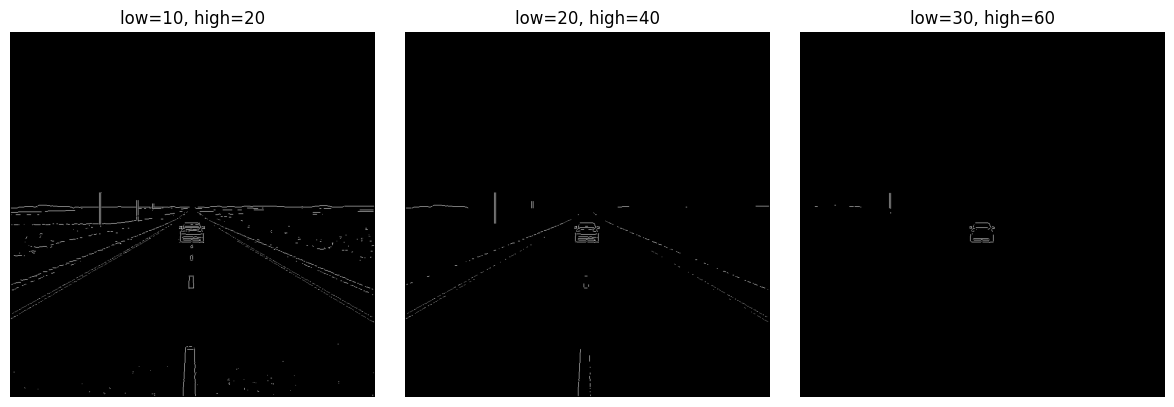

In [33]:
thresholds = [
    (10, 20),
    (20, 40),
    (30, 60)
]

results = []
titles = []

for low, high in thresholds:

    thresh = double_threshold(real_nms, low, high)
    edges = hysteresis(thresh)

    results.append(edges)
    titles.append(f"low={low}, high={high}")

show_grid(results, titles, ncols=3)

## Complete Canny Pipeline

Here we wrap all steps into a single `canny_edge_detector` function for convenient end-to-end use.


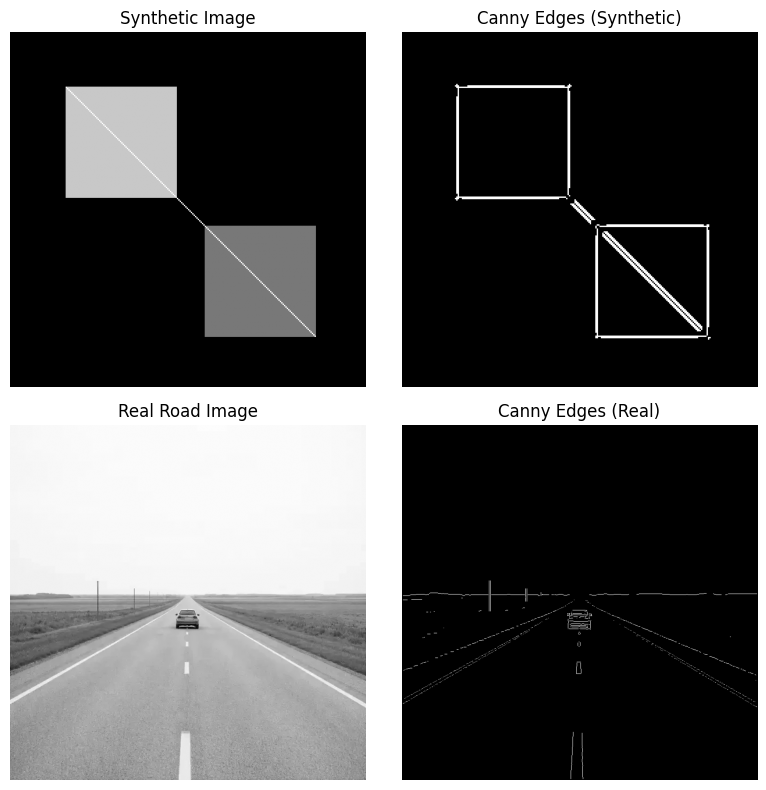

In [36]:
def canny_edge_detector(image, gauss_size=5, sigma=1.0, low=15, high=30):
    """
    Full Canny edge detection pipeline (from scratch).

    Steps:
      1. Gaussian smoothing
      2. Sobel gradient magnitude and direction
      3. Non-Maximum Suppression
      4. Double thresholding
      5. Edge tracking by hysteresis

    Parameters
    ----------
    image      : 2D uint8 numpy array (grayscale)
    gauss_size : Gaussian kernel size (odd)
    sigma      : Gaussian sigma
    low        : lower threshold for double threshold
    high       : upper threshold for double threshold

    Returns
    -------
    edges : 2D numpy array with values in {0, 255}
    """
    # Step 1: Gaussian smoothing
    kernel = gaussian_kernel(size=gauss_size, sigma=sigma)
    smoothed = convolve2d(image, kernel)

    # Step 2: Sobel gradients
    magnitude, direction = sobel_edges(smoothed)

    # Step 3: Non-Maximum Suppression
    nms = non_maximum_suppression(magnitude, direction)

    # Step 4: Double thresholding
    thresh = double_threshold(nms, low, high)

    # Step 5: Hysteresis
    edges = hysteresis(thresh)

    return edges


syn_edges  = canny_edge_detector(synthetic_img, gauss_size=5, sigma=1.0, low=15, high=30)
real_edges = canny_edge_detector(real_img,      gauss_size=5, sigma=1.0, low=15, high=30)

show_grid(
    [synthetic_img, syn_edges, real_img, real_edges],
    [
        "Synthetic Image",
        "Canny Edges (Synthetic)",
        "Real Road Image",
        "Canny Edges (Real)"
    ],
    ncols=2
)